# Exploratory Data Analysis (IPN Hand Dataset)

1. Understand annotation structure
2. Class distribution (balance check)
3. Gesture duration statistics
4. Visualize example frames
5. Identify potential issues for modeling

In [29]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data.dataset import (
    load_train_test, load_all_annotations, find_frames_dirs,
    find_video_dir, get_frame_paths, load_gesture_frames,
    print_stats, GESTURE_NAMES, CLASS_ID_TO_NAME
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = "../raw_data/raw"

## 1. Load annotations

In [30]:
train_df, test_df = load_train_test(DATA_DIR)

print_stats(train_df, "TRAIN (gestures only)")
print_stats(test_df, "TEST (gestures only)")

Train: 3117 gestures (from 4039 with non-gesture)
Test:  1101 gestures (from 1610 with non-gesture)
Classes: 13 gestures

  TRAIN (gestures only)
  Total samples:   3117
  Unique videos:   148
  Num classes:     13

  Class distribution:
    Point-1f         745 
    Point-2f         743 
    Throw-down       149 
    Zoom-out         148 
    Throw-left       148 
    Throw-up         148 
    Click-2f         148 
    DblClick-1f      148 
    Throw-right      148 
    Zoom-in          148 
    DblClick-2f      148 
    Open-twice       148 
    Click-1f         148 

  Gesture duration (frames, ~30fps):
    Min:         9  (0.3s)
    Max:       624  (20.8s)
    Mean:    139.4  (4.6s)
    Median:  113.0  (3.8s)


  TEST (gestures only)
  Total samples:   1101
  Unique videos:   52
  Num classes:     13

  Class distribution:
    Point-1f         265 
    Point-2f         264 
    Zoom-in           52 
    Open-twice        52 
    Zoom-out          52 
    Throw-right       52 
    T

In [31]:
# Preview first rows
print("=== TRAIN (first 10 rows) ===")
print(train_df.head(10).to_string())

=== TRAIN (first 10 rows) ===
           video label_code  class_id  start_frame  end_frame  n_frames gesture_name  label
0  1CM1_4_R_#229        G11        14           18         55        38     Zoom-out     12
1  1CM1_4_R_#229        B0B         3           56        284       229     Point-2f      1
2  1CM1_4_R_#229        G04         7          285        308        24   Throw-down      5
3  1CM1_4_R_#229        B0B         3          309        502       194     Point-2f      1
4  1CM1_4_R_#229        G05         8          503        544        42   Throw-left      6
5  1CM1_4_R_#229        B0B         3          545        857       313     Point-2f      1
6  1CM1_4_R_#229        G03         6          858        899        42     Throw-up      4
7  1CM1_4_R_#229        B0A         2          900       1122       223     Point-1f      0
8  1CM1_4_R_#229        G02         5         1433       1457        25     Click-2f      3
9  1CM1_4_R_#229        B0A         2         1458

## 2. Class distribution

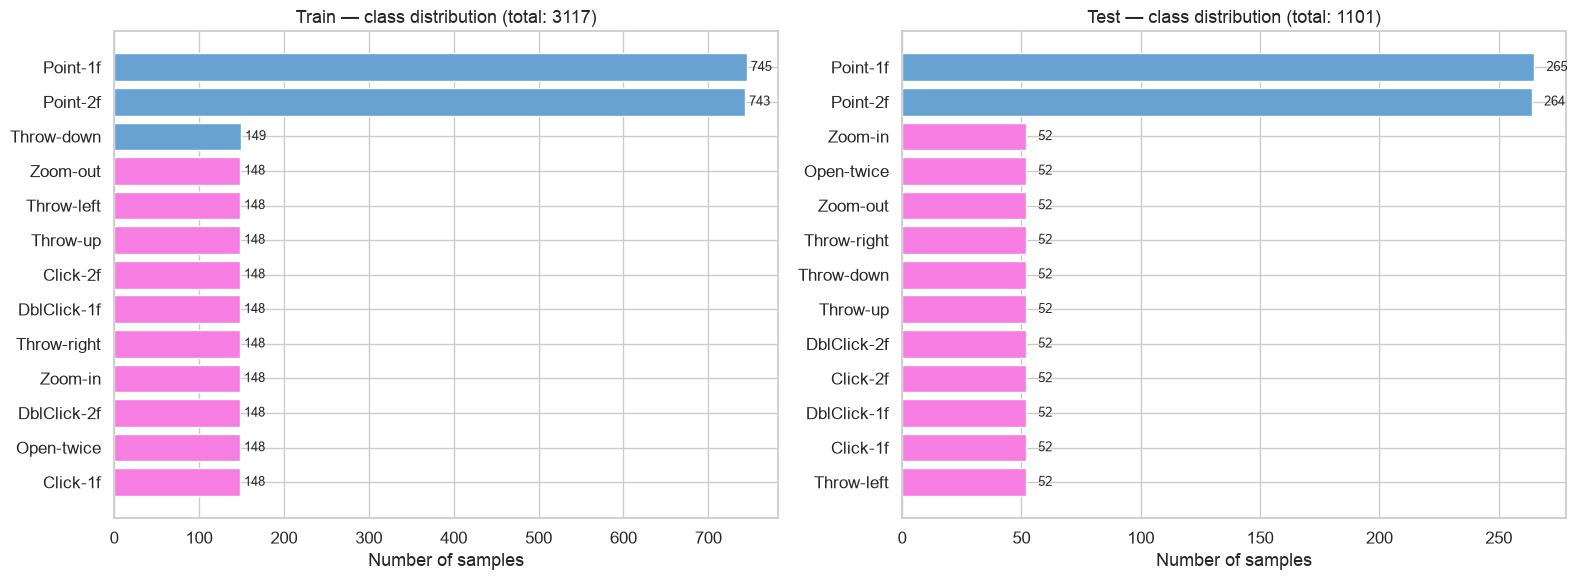

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df, title) in zip(axes, [(train_df, "Train"), (test_df, "Test")]):
    counts = df['gesture_name'].value_counts()
    colors = ["#67A2D2" if c > counts.median() else "#F67DE2" for c in counts.values]

    bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white')
    ax.set_xlabel('Number of samples')
    ax.set_title(f'{title} — class distribution (total: {len(df)})')
    ax.invert_yaxis()

    for bar, val in zip(bars, counts.values):
        ax.text(val + 5, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [33]:
# How imbalanced?
train_counts = train_df['gesture_name'].value_counts()
print(f"Most frequent class:  {train_counts.index[0]} ({train_counts.iloc[0]})")
print(f"Least frequent class: {train_counts.index[-1]} ({train_counts.iloc[-1]})")
print(f"Imbalance ratio:      {train_counts.iloc[0] / train_counts.iloc[-1]:.1f}x")

Most frequent class:  Point-1f (745)
Least frequent class: Click-1f (148)
Imbalance ratio:      5.0x


## 3. Gesture duration

/var/folders/6j/2rv38n4x0vxdxb1svr65xt7h0000gn/T/ipykernel_66276/4003151763.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, y='gesture_name', x='n_frames', order=order,


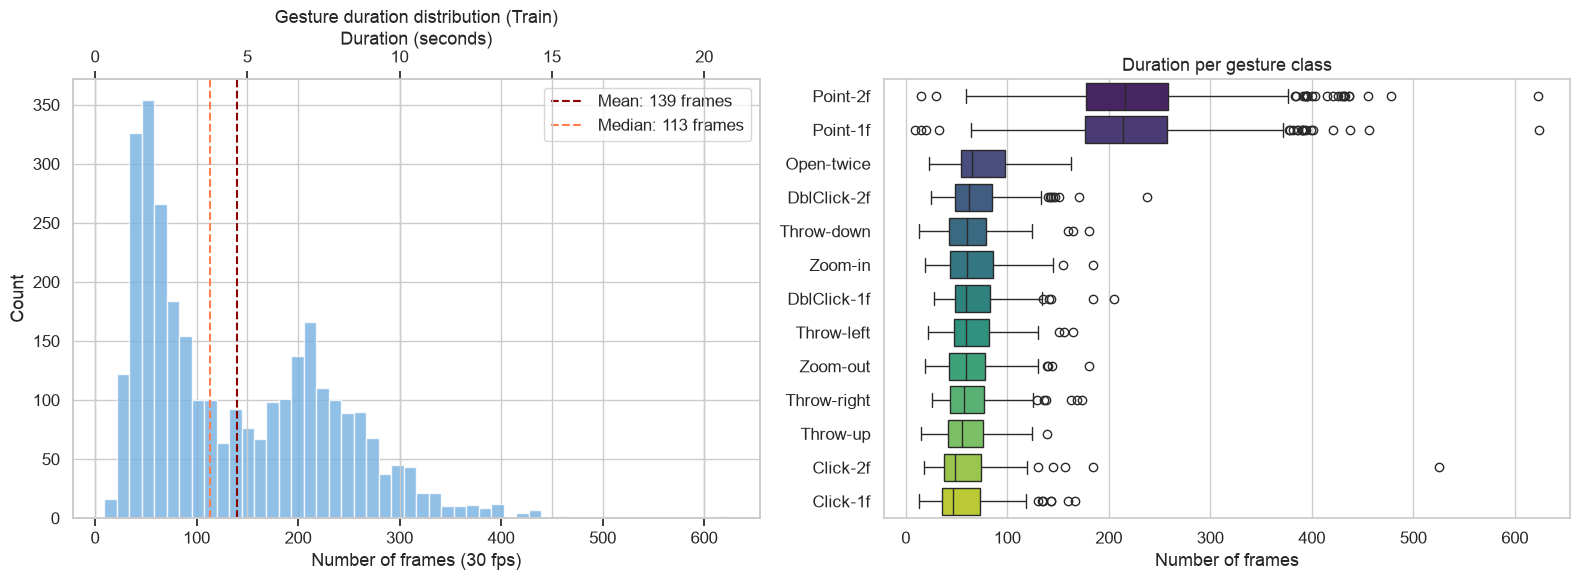

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax = axes[0]
ax.hist(train_df['n_frames'], bins=50, color="#76B1E1", edgecolor='white', alpha=0.8)
ax.axvline(train_df['n_frames'].mean(), color='darkred', linestyle='--',
           label=f"Mean: {train_df['n_frames'].mean():.0f} frames")
ax.axvline(train_df['n_frames'].median(), color='coral', linestyle='--',
           label=f"Median: {train_df['n_frames'].median():.0f} frames")
ax.set_xlabel('Number of frames (30 fps)')
ax.set_ylabel('Count')
ax.set_title('Gesture duration distribution (Train)')
ax.legend()

# Secondary x-axis in seconds
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()[0]/30, ax.get_xlim()[1]/30)
ax2.set_xlabel('Duration (seconds)')

# Box plot per class
ax = axes[1]
order = train_df.groupby('gesture_name')['n_frames'].median().sort_values(ascending=False).index
sns.boxplot(data=train_df, y='gesture_name', x='n_frames', order=order,
            ax=ax, palette='viridis', legend=False)
ax.set_xlabel('Number of frames')
ax.set_ylabel('')
ax.set_title('Duration per gesture class')

plt.tight_layout()
plt.show()

In [35]:
# Per-class stats
duration_stats = train_df.groupby('gesture_name')['n_frames'].agg(
    ['count', 'mean', 'std', 'min', 'max', 'median']
).round(1)
duration_stats['mean_sec'] = (duration_stats['mean'] / 30).round(2)
duration_stats = duration_stats.sort_values('mean', ascending=False)
print("\nDuration per class (frames @ 30fps):")
print(duration_stats.to_string())


Duration per class (frames @ 30fps):
              count   mean   std  min  max  median  mean_sec
gesture_name                                                
Point-2f        743  222.1  70.1   15  623   216.0      7.40
Point-1f        745  217.6  67.2    9  624   214.0      7.25
Open-twice      148   77.4  31.1   23  163    65.5      2.58
DblClick-2f     148   71.4  32.4   25  238    62.0      2.38
DblClick-1f     148   68.6  29.2   28  205    59.5      2.29
Zoom-in         148   67.0  29.9   19  184    60.0      2.23
Throw-left      148   66.7  27.8   22  165    59.0      2.22
Throw-down      149   65.6  29.0   13  181    60.0      2.19
Throw-right     148   64.9  29.5   26  174    57.0      2.16
Zoom-out        148   64.6  28.7   19  181    59.0      2.15
Throw-up        148   61.6  25.4   15  139    55.5      2.05
Click-2f        148   61.0  47.8   18  525    48.5      2.03
Click-1f        148   56.0  30.4   13  167    47.0      1.87


## 4. Static vs dynamic gestures

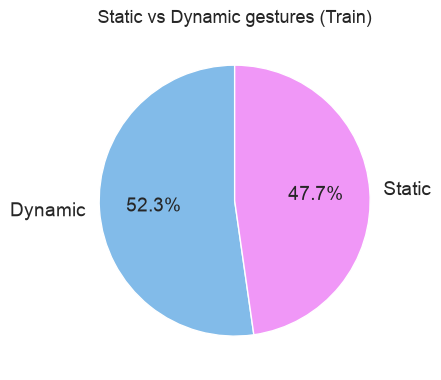


Static (Point-1f, Point-2f): 1488 samples
Dynamic (all others):        1629 samples

 Static gestures are ~48% of the dataset but only 2 of 13 classes — IMBALANCED!


In [36]:
static_gestures = ["Point-1f", "Point-2f"]
dynamic_gestures = [g for g in GESTURE_NAMES if g not in static_gestures]

train_df['gesture_type'] = train_df['gesture_name'].apply(
    lambda x: 'Static' if x in static_gestures else 'Dynamic'
)

fig, ax = plt.subplots(figsize=(8, 4))
type_counts = train_df['gesture_type'].value_counts()
ax.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
       colors=["#82BBE9", "#F097F7"], startangle=90,
       textprops={'fontsize': 14})
ax.set_title('Static vs Dynamic gestures (Train)')
plt.tight_layout()
plt.show()

print(f"\nStatic (Point-1f, Point-2f): {type_counts.get('Static', 0)} samples")
print(f"Dynamic (all others):        {type_counts.get('Dynamic', 0)} samples")
print(f"\n Static gestures are ~{type_counts.get('Static', 0) / len(train_df) * 100:.0f}% "
      f"of the dataset but only 2 of 13 classes — IMBALANCED!")

## 5. Per-video analysis

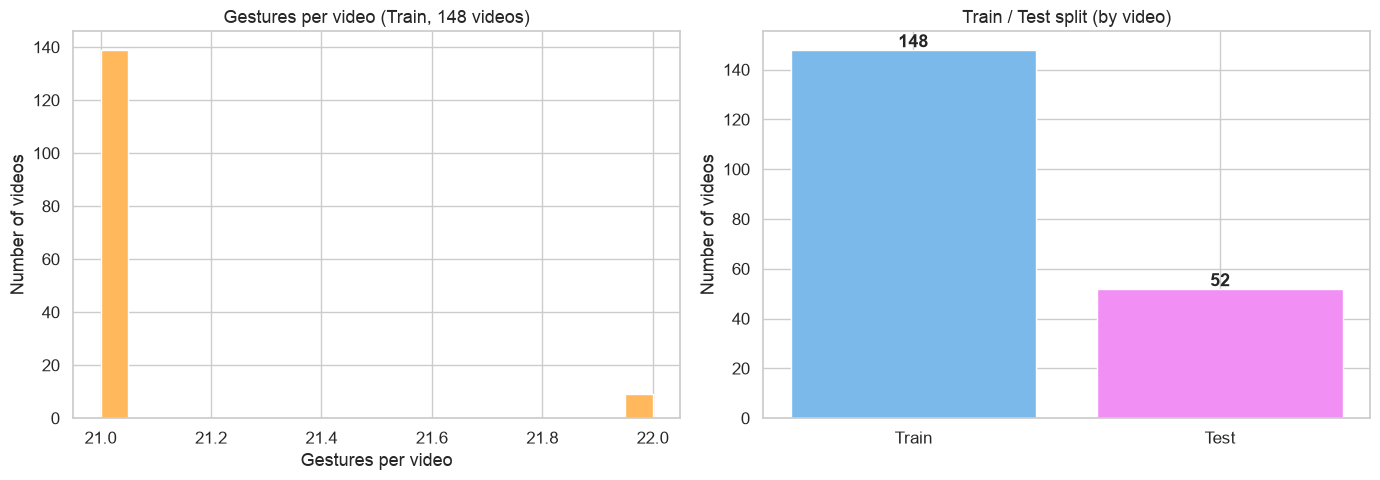

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gestures per video
gestures_per_video = train_df.groupby('video').size()
ax = axes[0]
ax.hist(gestures_per_video, bins=20, color="#FFB85B", edgecolor='white')
ax.set_xlabel('Gestures per video')
ax.set_ylabel('Number of videos')
ax.set_title(f'Gestures per video (Train, {train_df["video"].nunique()} videos)')

# Train vs test video count
ax = axes[1]
train_videos = train_df['video'].nunique()
test_videos = test_df['video'].nunique()
ax.bar(['Train', 'Test'], [train_videos, test_videos],
       color=["#7BB9EB", "#F18FF5"], edgecolor='white')
ax.set_ylabel('Number of videos')
ax.set_title('Train / Test split (by video)')
for i, v in enumerate([train_videos, test_videos]):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Visualize example frames

Found 5 frame directories: ['frames', 'frames 2', 'frames 3', 'frames 4', 'frames 5']


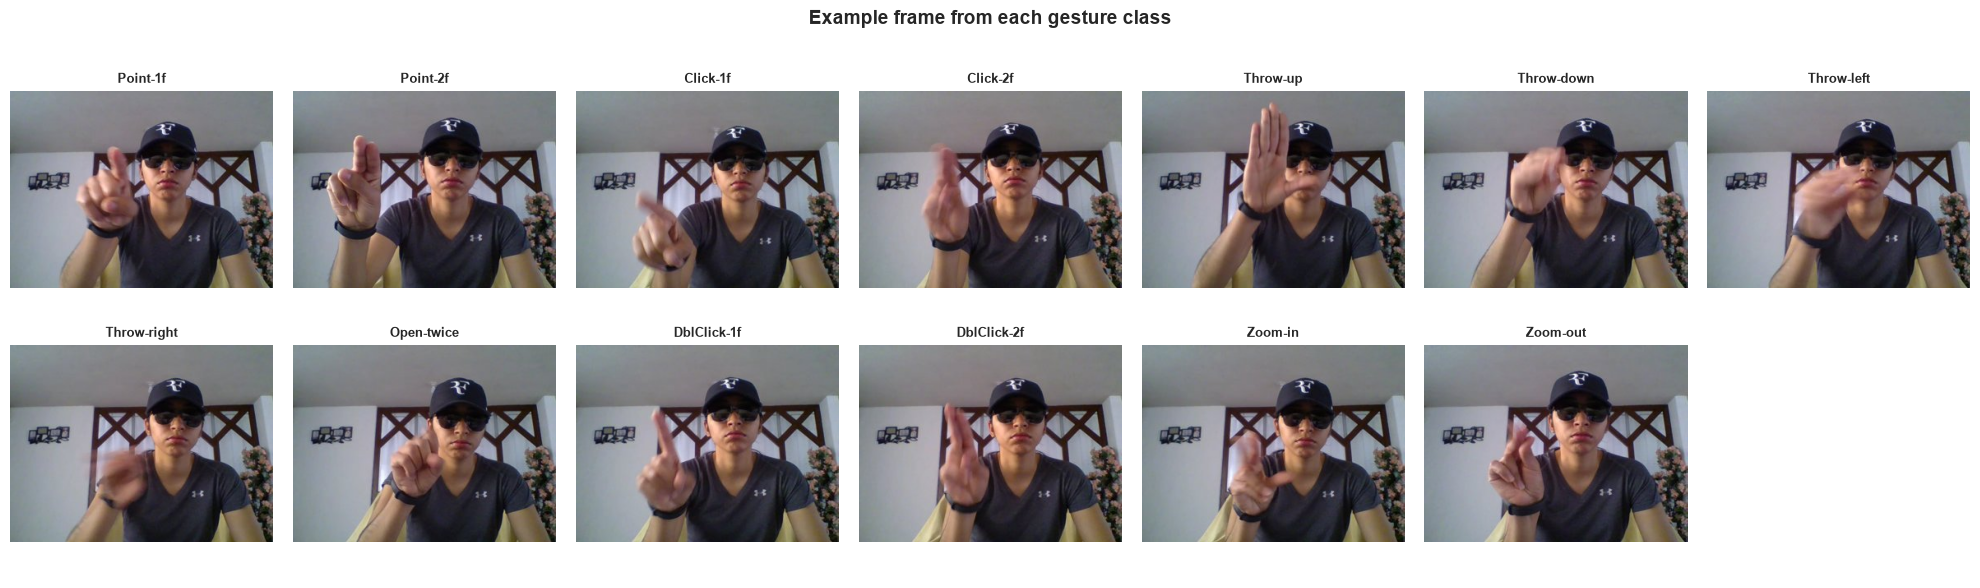

In [38]:
frame_dirs = find_frames_dirs(DATA_DIR)

if frame_dirs:
    # Show one example frame per class
    fig, axes = plt.subplots(2, 7, figsize=(20, 6))
    axes = axes.flatten()

    for i, gesture in enumerate(GESTURE_NAMES):
        ax = axes[i]
        sample = train_df[train_df['gesture_name'] == gesture].iloc[0]

        # Load the middle frame of the gesture
        mid_frame = (sample['start_frame'] + sample['end_frame']) // 2
        frames = load_gesture_frames(
            sample['video'], mid_frame, mid_frame, frame_dirs
        )

        if frames is not None and len(frames) > 0:
            ax.imshow(frames[0])
        else:
            ax.text(0.5, 0.5, 'No frame\nfound', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10)

        ax.set_title(gesture, fontsize=9, fontweight='bold')
        ax.axis('off')

    if len(GESTURE_NAMES) < len(axes):
        axes[-1].axis('off')

    plt.suptitle('Example frame from each gesture class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Frame directories not found in", DATA_DIR)
    print("Skipping frame visualization.")

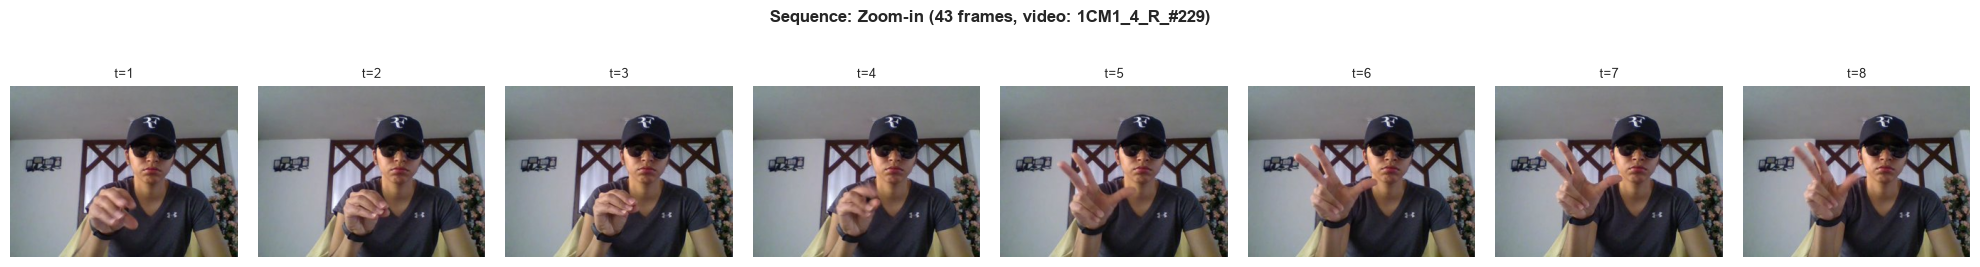

In [39]:
# Show a gesture sequence (to see the motion)
if frame_dirs:
    sample = train_df[train_df['gesture_name'] == 'Zoom-in'].iloc[0]
    frames = load_gesture_frames(
        sample['video'], sample['start_frame'], sample['end_frame'],
        frame_dirs, max_frames=8
    )

    if frames is not None:
        fig, axes = plt.subplots(1, len(frames), figsize=(20, 3))
        for j, (ax, frm) in enumerate(zip(axes, frames)):
            ax.imshow(frm)
            ax.set_title(f"t={j+1}", fontsize=9)
            ax.axis('off')

        plt.suptitle(f'Sequence: {sample["gesture_name"]} '
                     f'({sample["n_frames"]} frames, video: {sample["video"]})',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

## 7. Frame coverage check

In [40]:
if frame_dirs:
    found = 0
    missing = 0
    missing_videos = set()

    for _, row in train_df.sample(min(100, len(train_df)), random_state=42).iterrows():
        vdir = find_video_dir(row['video'], frame_dirs)
        if vdir is not None:
            paths = get_frame_paths(vdir, row['start_frame'], row['end_frame'])
            if len(paths) > 0:
                found += 1
            else:
                missing += 1
                missing_videos.add(row['video'])
        else:
            missing += 1
            missing_videos.add(row['video'])

    total_checked = found + missing
    print(f"Frame coverage check (sample of {total_checked} gestures):")
    print(f"   Found:   {found}/{total_checked} ({found/total_checked*100:.0f}%)")
    print(f"   Missing: {missing}/{total_checked} ({missing/total_checked*100:.0f}%)")
    if missing_videos:
        print(f"  Videos without frames: {list(missing_videos)[:5]}...")

Frame coverage check (sample of 100 gestures):
   Found:   100/100 (100%)
   Missing: 0/100 (0%)


## 8. Summary

In [41]:
print("=" * 60)
print("  Exploration data analysis SUMMARY")
print("=" * 60)
print(f"""
  Dataset:         IPN Hand
  Train gestures:  {len(train_df)}
  Test gestures:   {len(test_df)}
  Classes:         {len(GESTURE_NAMES)} (excluding non-gesture)

   IMBALANCE:
    - Point-1f and Point-2f have ~5x more samples than others
    - Solution: class weights in loss or stratified sampling

   DURATION:
    - Static gestures (Point) last ~7s
    - Dynamic gestures last ~2s
    - For LSTM/3D-CNN: pad or uniformly sample to fixed length
    - Recommended T_fixed: {int(train_df['n_frames'].quantile(0.75))} frames
      (75th percentile)

   FRAMES:
    - Resolution: 320x240 (resized version)
    - Format: video_name_{{NNNNNN}}.jpg
    - 5 folders (frames, frames 2, ... frames 5)
""")
print("=" * 60)

  Exploration data analysis SUMMARY

  Dataset:         IPN Hand
  Train gestures:  3117
  Test gestures:   1101
  Classes:         13 (excluding non-gesture)

   IMBALANCE:
    - Point-1f and Point-2f have ~5x more samples than others
    - Solution: class weights in loss or stratified sampling

   DURATION:
    - Static gestures (Point) last ~7s
    - Dynamic gestures last ~2s
    - For LSTM/3D-CNN: pad or uniformly sample to fixed length
    - Recommended T_fixed: 212 frames
      (75th percentile)

   FRAMES:
    - Resolution: 320x240 (resized version)
    - Format: video_name_{NNNNNN}.jpg
    - 5 folders (frames, frames 2, ... frames 5)

